1. Import the libraries

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# These are used only for the required statistical tests
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu

2. Load the dataset

In [57]:
df = pd.read_csv('/content/drive/MyDrive/Ecommerce/master_cleaned.csv')
print("Dataset loaded successfully")

Dataset loaded successfully


3. The first five rows

In [58]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,total_payment_value,payment_installments,payment_types_used,total_items,total_freight,total_price,review_score,delivery_days,delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,38.71,1.0,"credit_card,voucher",1.0,8.72,29.99,4.0,8.0,-8.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,141.46,1.0,boleto,1.0,22.76,118.70,4.0,13.0,-6.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,179.12,3.0,credit_card,1.0,19.22,159.90,5.0,9.0,-18.0,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,72.20,1.0,credit_card,1.0,27.20,45.00,5.0,13.0,-13.0,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,28.62,1.0,credit_card,1.0,8.72,19.90,5.0,2.0,-10.0,False


4. Understand the row grain

In [59]:
print("Number of rows: ", len(df))
print("Number of columns: ", len(df.columns))
print("Unique order IDs: ",df['order_id'].nunique())

Number of rows:  99441
Number of columns:  22
Unique order IDs:  99441


5. Check column names and data types

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  object 
 1   customer_id                    99441 non-null  object 
 2   order_status                   99441 non-null  object 
 3   order_purchase_timestamp       99441 non-null  object 
 4   order_approved_at              99281 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  99441 non-null  object 
 8   customer_unique_id             99441 non-null  object 
 9   customer_zip_code_prefix       99441 non-null  int64  
 10  customer_city                  99441 non-null  object 
 11  customer_state                 99441 non-null  object 
 12  total_payment_value            99440 non-null 

6. Check missing values

In [61]:
missing_values = df.isnull().sum()
missing_values = missing_values.sort_values(ascending=False)
print(missing_values)

delivery_days                    2965
order_delivered_customer_date    2965
delay_days                       2965
is_late                          2965
order_delivered_carrier_date     1783
total_items                       775
total_price                       775
total_freight                     775
review_score                      768
order_approved_at                 160
payment_installments                1
total_payment_value                 1
payment_types_used                  1
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_id                            0
customer_city                       0
order_estimated_delivery_date       0
customer_state                      0
customer_unique_id                  0
customer_zip_code_prefix            0
dtype: int64


7. Check duplicate orders

In [62]:
duplicate_orders = df['order_id'].duplicated().sum()
print("Duplicate order IDs: ",duplicate_orders)

Duplicate order IDs:  0


8. Convert date columns into datetime format

In [63]:
df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp'],
    errors='coerce'
)

df['order_approved_at'] = pd.to_datetime(
    df['order_approved_at'],
    errors='coerce'
)

df['order_delivered_carrier_date'] = pd.to_datetime(
    df['order_delivered_carrier_date'],
    errors='coerce'
)

df['order_delivered_customer_date'] = pd.to_datetime(
    df['order_delivered_customer_date'],
    errors='coerce'
)

df['order_estimated_delivery_date'] = pd.to_datetime(
    df['order_estimated_delivery_date'],
    errors='coerce'
)

9. Make the late-delivery column easier to use

In [64]:
# Convert text True/False into real Boolean values
df['is_late'] = df['is_late'].replace({
    'True': True,
    'False': False
})

df['is_late'] = df['is_late'].astype('boolean')

df['is_late'].value_counts(dropna=False)

,count
is_late,
False,89941
True,6535
<NA>,2965


10. Basic numerical summary

In [65]:
numeric_columns = [
    'total_payment_value',
    'payment_installments',
    'total_items',
    'total_freight',
    'total_price',
    'review_score',
    'delivery_days',
    'delay_days'
]

df[numeric_columns].describe().round(2)

,total_payment_value,payment_installments,total_items,total_freight,total_price,review_score,delivery_days,delay_days
count,99440.00,99440.00,98666.00,98666.00,98666.00,98673.00,96476.00,96476.00
mean,160.99,2.93,1.14,22.82,137.75,4.09,12.09,-11.88
std,221.95,2.72,0.54,21.65,210.65,1.35,9.55,10.18
min,0.00,0.00,1.00,0.00,0.85,1.00,0.00,-147.00
25%,62.01,1.00,1.00,13.85,45.90,4.00,6.00,-17.00
50%,105.29,2.00,1.00,17.17,86.90,5.00,10.00,-12.00
75%,176.97,4.00,1.00,24.04,149.90,5.00,15.00,-7.00
max,13664.08,24.00,21.00,1794.96,13440.00,5.00,209.00,188.00


12. Order status analysis

In [66]:
order_status_counts = df['order_status'].value_counts()
print(order_status_counts)

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


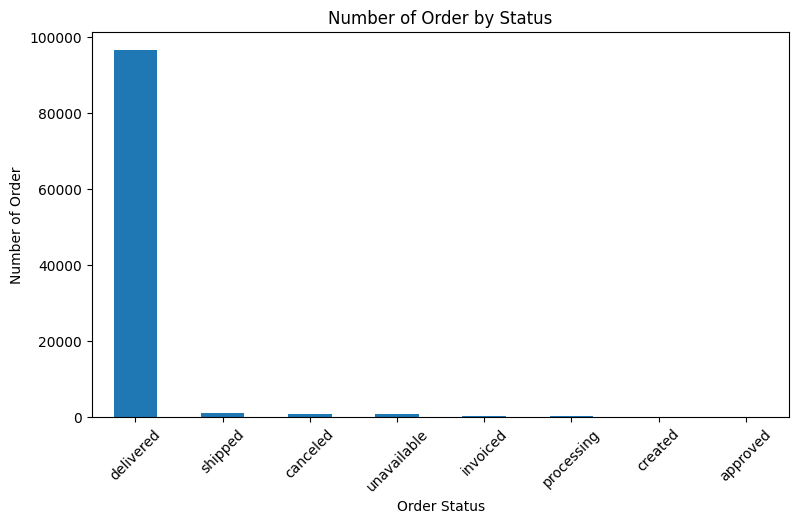

In [67]:
order_status_counts.plot(
    kind='bar',
    title='Number of Order by Status',
    xlabel='Order Status',
    ylabel='Number of Order',
    figsize=(9,5)
)
plt.xticks(rotation=45)
plt.show()

13. Distribution of order payment values

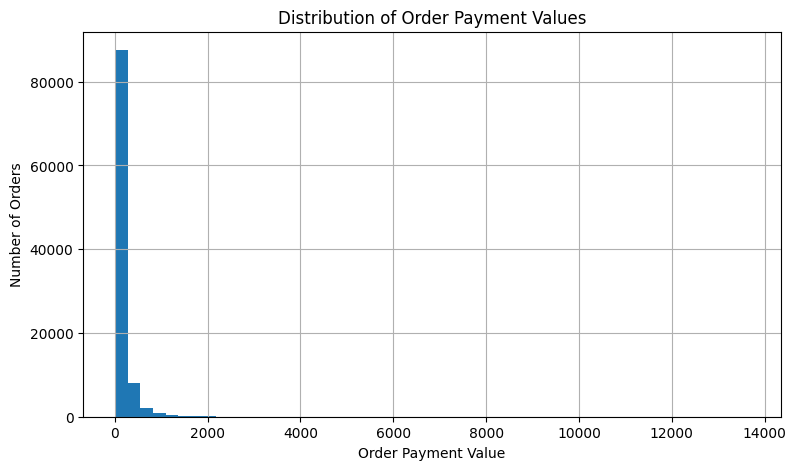

In [68]:
df['total_payment_value'].hist(
    bins =50,
    figsize=(9,5),
)
plt.xlabel('Order Payment Value')
plt.ylabel('Number of Orders')
plt.title('Distribution of Order Payment Values')
plt.show()

In [69]:

payment_mean = df['total_payment_value'].mean()
payment_median = df['total_payment_value'].median()
payment_skew = df['total_payment_value'].skew()

print("Mean payment value:", round(payment_mean, 2))
print("Median payment value:", round(payment_median, 2))
print("Skewness:", round(payment_skew, 2))

Mean payment value: 160.99
Median payment value: 105.29
Skewness: 9.15


14. Review score distribution

In [70]:
review_count = df['review_score'].value_counts().sort_index()
print(review_count)

review_score
1.0    11363
2.0     3131
3.0     8133
4.0    19038
5.0    57008
Name: count, dtype: int64


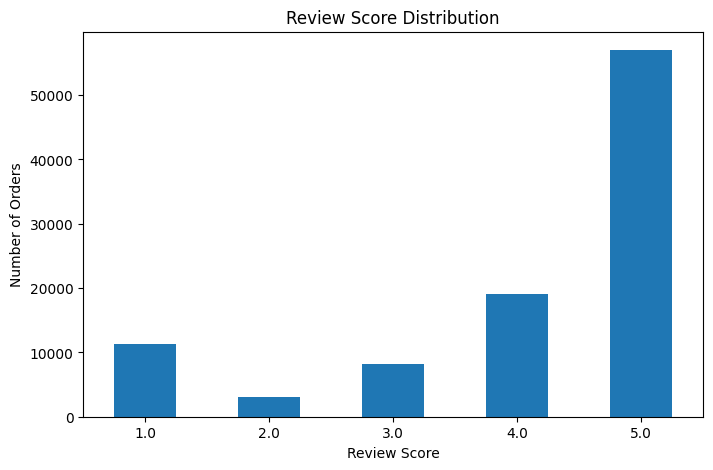

In [71]:
review_count.plot(
    kind='bar',
    figsize=(8, 5),
    title='Review Score Distribution'
)

plt.xlabel('Review Score')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()

15. Delivery-time distribution

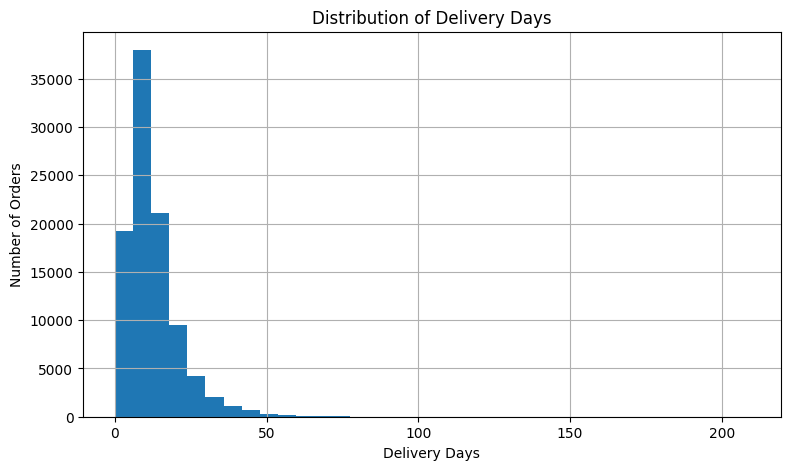

In [72]:
df['delivery_days'].hist(
    bins=35,
    figsize=(9, 5)
)

plt.title('Distribution of Delivery Days')
plt.xlabel('Delivery Days')
plt.ylabel('Number of Orders')
plt.show()

In [73]:
print("Average delivery days:", round(df['delivery_days'].mean(), 2))
print("Median delivery days:", round(df['delivery_days'].median(), 2))
print("Delivery-day skewness:", round(df['delivery_days'].skew(), 2))


Average delivery days: 12.09
Median delivery days: 10.0
Delivery-day skewness: 3.83


16. Orders and revenue by customer state

In [74]:
state_summary = df.groupby('customer_state').agg(
    orders=('order_id', 'nunique'),
    revenue=('total_payment_value', 'sum')
)

state_summary = state_summary.sort_values(by='revenue', ascending=False)
state_summary.head(10)

,orders,revenue
customer_state,,
SP,41746,5998226.96
RJ,12852,2144379.69
MG,11635,1872257.26
RS,5466,890898.54
PR,5045,811156.38
SC,3637,623086.43
BA,3380,616645.82
DF,2140,355141.08
GO,2020,350092.31


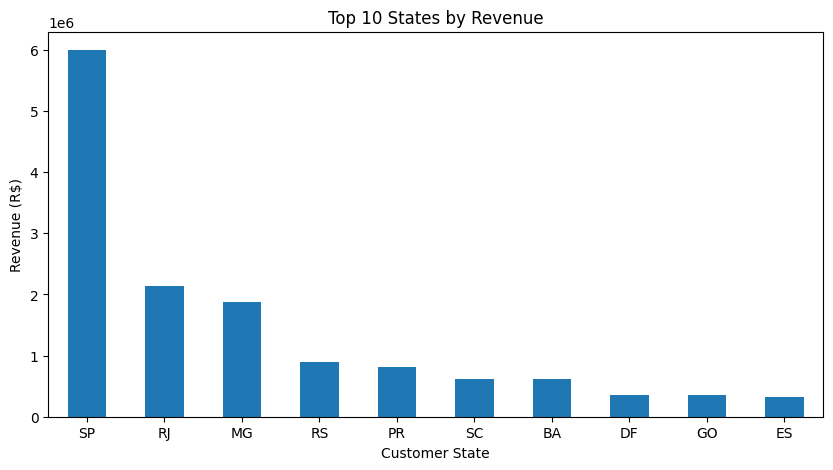

In [75]:
state_summary.head(10)['revenue'].plot(
    kind='bar',
    figsize=(10, 5),
    title='Top 10 States by Revenue'
)

plt.xlabel('Customer State')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=0)
plt.show()

17. Monthly order and revenue trend

In [76]:
df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

monthly_summary = df.groupby('purchase_month').agg(
    orders=('order_id', 'nunique'),
    revenue=('total_payment_value', 'sum')
)

monthly_summary.tail()

,orders,revenue
purchase_month,,
2018-06,6167,1023880.50
2018-07,6292,1066540.75
2018-08,6512,1022425.32
2018-09,16,4439.54
2018-10,4,589.67


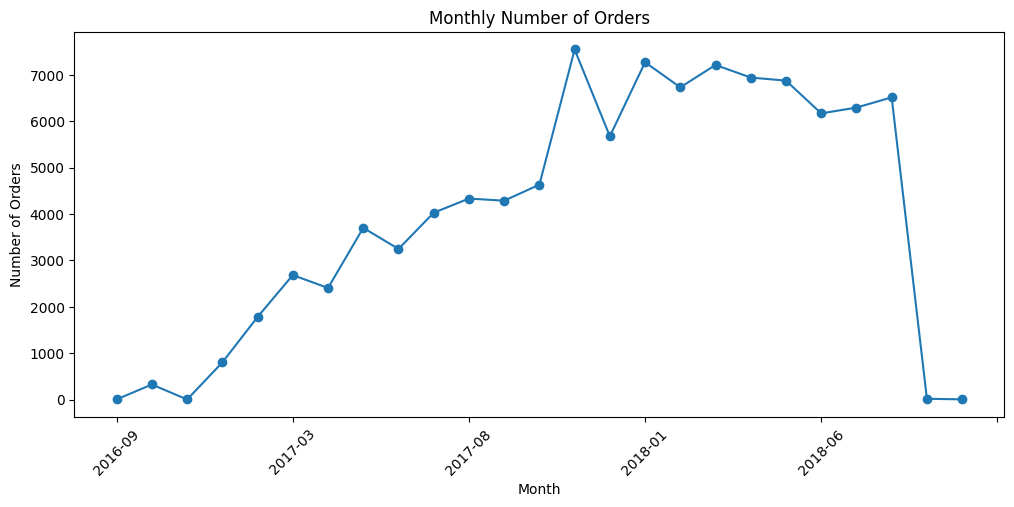

In [77]:
monthly_summary['orders'].plot(
    figsize=(12,5),
    marker = 'o',
    title='Monthly Number of Orders'
)

plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

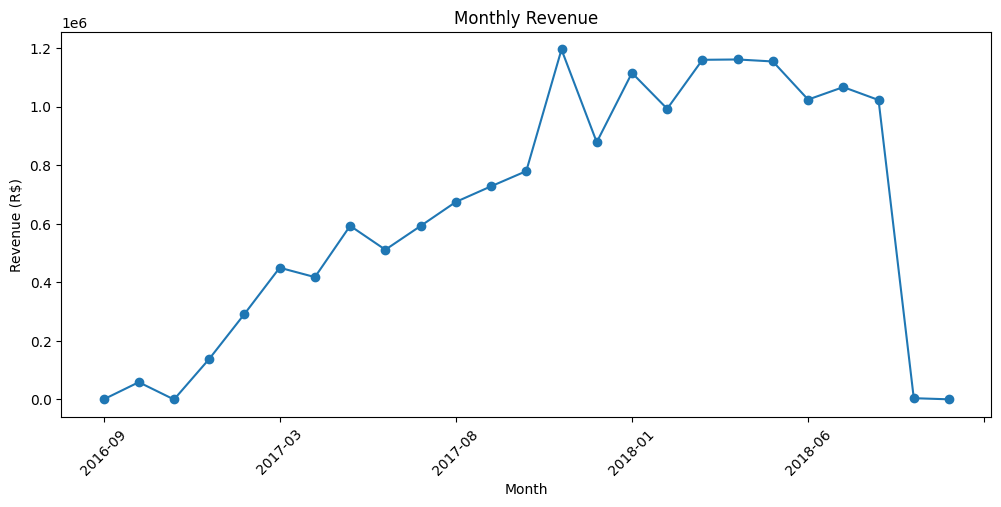

In [78]:
monthly_summary['revenue'].plot(
    figsize=(12, 5),
    marker='o',
    title='Monthly Revenue'
)

plt.xlabel('Month')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=45)
plt.show()

18. Payment-Method analysis

In [79]:
payment_methods = df['payment_types_used'].dropna().str.split(',').explode()

payment_method_count = payment_methods.value_counts()

payment_method_count

,count
payment_types_used,
credit_card,76505
boleto,19784
voucher,3866
debit_card,1528
not_defined,3


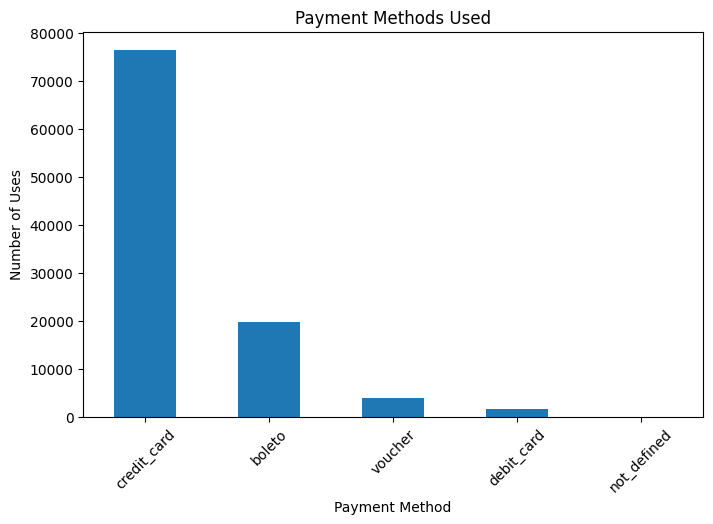

In [80]:
payment_method_count.plot(
    kind='bar',
    figsize=(8, 5),
    title='Payment Methods Used'
)

plt.xlabel('Payment Method')
plt.ylabel('Number of Uses')
plt.xticks(rotation=45)
plt.show()

19. Late-delivery rate

In [81]:
late_rate = df['is_late'].mean()

print("Late-delivery rate:", round(late_rate * 100, 2), "%")

Late-delivery rate: 6.77 %


20. Average review score for late and on-time orders

In [82]:
review_by_late_status = df.groupby('is_late')['review_score'].agg([
    'count',
    'mean',
    'median'
])

review_by_late_status.round(2)

,count,mean,median
is_late,,,
False,89448,4.29,5.0
True,6382,2.27,1.0


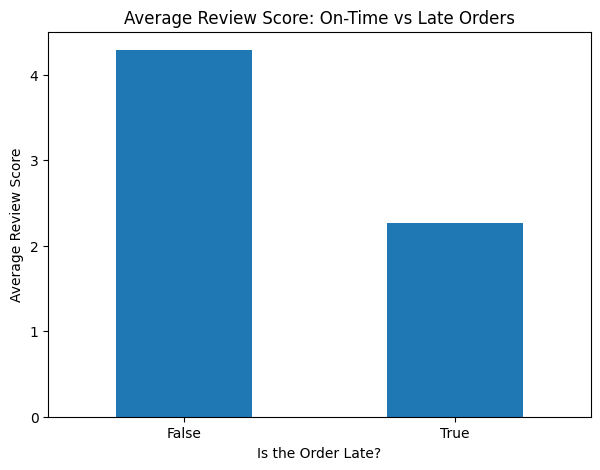

In [83]:
review_by_late_status['mean'].plot(
    kind='bar',
    figsize=(7, 5),
    title='Average Review Score: On-Time vs Late Orders'
)

plt.xlabel('Is the Order Late?')
plt.ylabel('Average Review Score')
plt.xticks(rotation=0)
plt.show()

21. Scatter plot: delivery days and review score

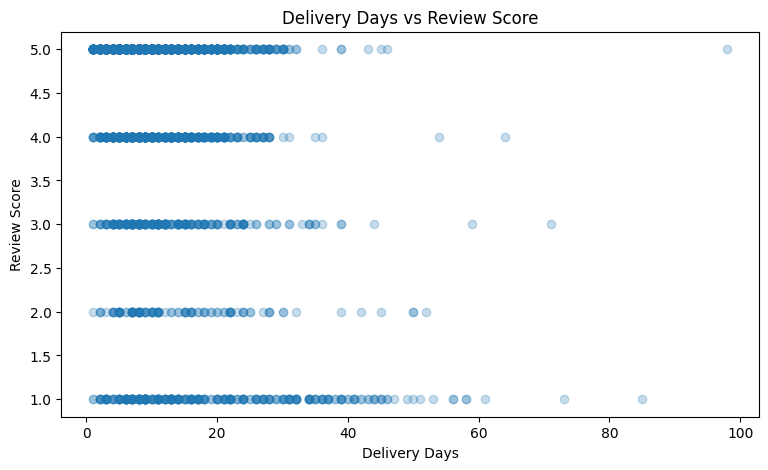

In [84]:
plot_data = df[
    ['delivery_days', 'review_score']
].dropna()

# A smaller sample keeps the chart clear
plot_data = plot_data.sample(
    n=3000,
    random_state=42
)

plt.figure(figsize=(9, 5))
plt.scatter(
    plot_data['delivery_days'],
    plot_data['review_score'],
    alpha=0.25
)

plt.title('Delivery Days vs Review Score')
plt.xlabel('Delivery Days')
plt.ylabel('Review Score')
plt.show()

22. Spearman correlation test

In [85]:
correlation_data = df[
    ['delivery_days', 'review_score']
].dropna()

spearman_r, spearman_p = spearmanr(
    correlation_data['delivery_days'],
    correlation_data['review_score']
)

print("Spearman correlation:", round(spearman_r, 3))
print("p-value:", spearman_p)

Spearman correlation: -0.235
p-value: 0.0
